<a href="https://colab.research.google.com/github/edwardcalvinvazc-maker/Sentiment-Analysis/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers torch

In [3]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.4 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import nltk
import gensim
import torch
import sklearn
import xgboost as xgb
import yfinance as yf
import websockets

In [5]:
from datasets import load_dataset

df = load_dataset("cyrilzhang/financial_phrasebank_split")

README.md:   0%|          | 0.00/578 [00:00<?, ?B/s]

data/train-00000-of-00001-500b955d77e781(…): reconstructing file:   0%|          |  0.00B /  376kB            

data/train-00000-of-00001-500b955d77e781(…): downloading bytes:           |  0.00B            

data/test-00000-of-00001-08257c1f0eb1877(…): reconstructing file:   0%|          |  0.00B / 42.3kB            

data/test-00000-of-00001-08257c1f0eb1877(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/4361 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/485 [00:00<?, ? examples/s]

In [6]:
df_train = df['train'].to_pandas()
df_test = df['test'].to_pandas()
traget = df_test.label
df_test = df_test.drop('label',axis=1)
print(df_train.head())
print(df_train.shape)
print(traget.head)
print(df_test.head())

                                            sentence  label
0  The Lemminkainen Group , headquartered in Hels...      1
1  The paper industry 's de-inking sludge , which...      1
2  The EBITDA was EUR116m compared to EUR115m , c...      2
3  In a release , the Company said that Vocollect...      2
4  It is necessary to strengthen the company 's o...      1
(4361, 2)
<bound method NDFrame.head of 0      1
1      1
2      1
3      1
4      1
      ..
480    1
481    0
482    1
483    2
484    0
Name: label, Length: 485, dtype: int64>
                                            sentence
0  Aldata said that there are still a number of o...
1  The Nokia Music Store begins trading on Tuesda...
2  The Line 4 will run fully underground and will...
3  The contractor of the shopping center , China ...
4  Press release 3 September 2009 Ruukki continue...


In [7]:
print(df_train.shape)
df_test.shape

(4361, 2)


(485, 1)

In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4361 entries, 0 to 4360
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentence  4361 non-null   object
 1   label     4361 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 68.3+ KB


In [9]:
df_test.head()

,sentence
0,Aldata said that there are still a number of o...
1,The Nokia Music Store begins trading on Tuesda...
2,The Line 4 will run fully underground and will...
3,"The contractor of the shopping center , China ..."
4,Press release 3 September 2009 Ruukki continue...


In [10]:
## Converting to lowercase and removing special characters


df_train['sentence'] = df_train['sentence'].str.lower()
df_test['sentence'] = df_test['sentence'].str.lower()

df_train['sentence'] = df_train['sentence'].str.replace(r'[.,]', '', regex=True)
df_test['sentence'] = df_test['sentence'].str.replace(r'[.,]', '', regex=True)

print("Train head after cleaning:")
display(df_train.head())

Train head after cleaning:


,sentence,label
0,the lemminkainen group headquartered in helsi...,1
1,the paper industry 's de-inking sludge which ...,1
2,the ebitda was eur116m compared to eur115m co...,2
3,in a release the company said that vocollect ...,2
4,it is necessary to strengthen the company 's o...,1


In [11]:
from sklearn.model_selection import train_test_split

# Splitting df_train into training and validation sets (80/20 split)
df_train_split, df_val_split = train_test_split(
    df_train,
    test_size=0.2,
    random_state=42,
    stratify=df_train['label']
)

print(f"Original train shape: {df_train.shape}")
print(f"New train shape: {df_train_split.shape}")
print(f"Validation shape: {df_val_split.shape}")

display(df_val_split.head())

Original train shape: (4361, 2)
New train shape: (3488, 2)
Validation shape: (873, 2)


,sentence,label
1389,may 29 2010 ( companiesandmarketscom delivere...,1
2605,the event can be followed on-line via orion 's...,1
3505,part of the reductions will be made through re...,1
651,the company has decided to stop the operations...,1
2515,fiskars will be undertaking community projects...,1


### Tokenization and Word Vectorization
We will now break the sentences into tokens (words) and use `gensim` to train a Word2Vec model. This will represent each word as a vector in a high-dimensional space.

In [12]:
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import nltk


nltk.download('punkt')
nltk.download('punkt_tab')

# Tokenize the training sentences
train_sentences = [word_tokenize(s) for s in df_train_split['sentence']]

# Train Word2Vec model
w2v_model = Word2Vec(sentences=train_sentences, vector_size=100, window=5, min_count=1, workers=4)

print(f"Word2Vec model trained with vocabulary size: {len(w2v_model.wv)}")

# Example: Vector for the word 'company'
if 'company' in w2v_model.wv:
    print("Vector for 'company':", w2v_model.wv['company'][:10], "...")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Word2Vec model trained with vocabulary size: 9445
Vector for 'company': [-0.5311215   0.7352847   0.1933319   0.58181906  0.19024934 -1.3528255
  0.37840393  1.8953087  -0.61474365 -0.85111827] ...


### Sentence Embedding
To classify whole sentences, we need a single vector per sentence. A common simple approach is to take the average of all word vectors in that sentence.

In [13]:
def get_sentence_vector(sentence, model):
    words = word_tokenize(sentence)
    vectors = [model.wv[w] for w in words if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

# Transform splits into vector features
X_train = np.array([get_sentence_vector(s, w2v_model) for s in df_train_split['sentence']])
X_val = np.array([get_sentence_vector(s, w2v_model) for s in df_val_split['sentence']])

y_train = df_train_split['label'].values
y_val = df_val_split['label'].values


print(f"Feature matrix shapes: Train {X_train.shape}, Val {X_val.shape}")

Feature matrix shapes: Train (3488, 100), Val (873, 100)


### Evaluating the Stacking Ensemble
We will now generate predictions using the `stack_clf` and compare its performance metrics (Accuracy and Macro F1-Score) against the validation set.

In [31]:
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on validation set using the stacked model
y_val_pred_stack = stack_clf.predict(X_val)

# Calculate metrics
stack_accuracy = accuracy_score(y_val, y_val_pred_stack)
stack_macro_f1 = f1_score(y_val, y_val_pred_stack, average='macro')

print(f"Stacking Classifier Validation Accuracy: {stack_accuracy:.2%}")
print(f"Stacking Classifier Macro F1-Score: {stack_macro_f1:.4f}")
print("\nClassification Report:")
# class_names was defined in previous cells as ['Negative (0)', 'Neutral (1)', 'Positive (2)']
print(classification_report(y_val, y_val_pred_stack, target_names=class_names))

Stacking Classifier Validation Accuracy: 60.25%
Stacking Classifier Macro F1-Score: 0.4315

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.30      0.50      0.38       109
 Neutral (1)       0.71      0.87      0.78       517
Positive (2)       0.38      0.09      0.14       247

    accuracy                           0.60       873
   macro avg       0.46      0.48      0.43       873
weighted avg       0.56      0.60      0.55       873



In [36]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold

## Estimator Model 1: XGBoost
# Note: For multiclass, sample weights are usually handled during .fit(),
# but we can tune depth and subsampling to prevent overfitting the majority class.
xgb_clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2,
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)

## Estimator Model 2: RandomForest
# Adding class_weight='balanced' to help with the under-represented classes
rfc_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=5,
    min_samples_leaf=2,
    class_weight='balanced',
    n_jobs=-1
)

## Base Models List
base_estimators = [("xgb_clf", xgb_clf), ("rfc_clf", rfc_clf)]

## Final Model: LogisticRegression
# Using class_weight='balanced' here as well to penalize misclassifying minority sentiments
final_estimator = LogisticRegression(max_iter=3000, class_weight='balanced', C=0.1)

## Stacking the Models
stack_clf = StackingClassifier(
    estimators=base_estimators,
    stack_method="predict_proba",
    final_estimator=final_estimator,
    cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=42),
    passthrough=False
)

# Fit the optimized stack
stack_clf.fit(X_train, y_train)

# Calculate and print score
score = stack_clf.score(X_train, y_train)
print(f"Updated Stacking Training Score: {score:.4f}")

Updated Stacking Training Score: 0.6296


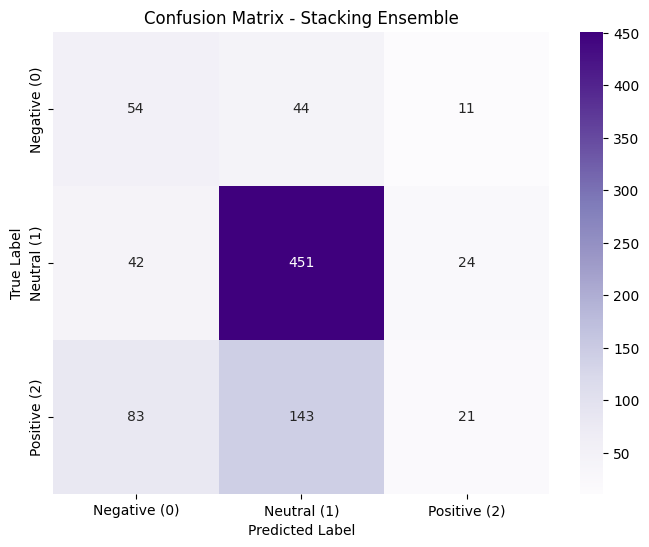

In [32]:
# Plot Stacking Confusion Matrix
cm_stack = confusion_matrix(y_val, y_val_pred_stack)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Stacking Ensemble')
plt.show()

### Hyperparameter Tuning with GridSearchCV
We will define a grid of potential parameters for the XGBoost model and use 3-fold cross-validation to find the best combination.

In [33]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.7, 0.9]
}

# Initialize the XGBClassifier
xgb_tune = XGBClassifier(eval_metric='mlogloss', random_state=42)

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_tune,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Training Accuracy: {grid_search.best_score_:.2%}")

# Evaluate on validation set
best_model = grid_search.best_estimator_
y_val_tuned = best_model.predict(X_val)
print(f"Tuned Validation Accuracy: {accuracy_score(y_val, y_val_tuned):.2%}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.7}
Best Training Accuracy: 62.82%
Tuned Validation Accuracy: 64.15%


### Training the XGBoost Model


In [34]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the XGBoost Classifier with L2 Regularization (reg_lambda)
# Removed deprecated use_label_encoder to suppress warnings
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    reg_lambda=2,      # L2 regularization term on weights
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = xgb_model.predict(X_val)

# Evaluate performance
accuracy = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy with L2: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Validation Accuracy with L2: 64.72%

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.14      0.22       109
           1       0.68      0.94      0.79       517
           2       0.49      0.26      0.34       247

    accuracy                           0.65       873
   macro avg       0.59      0.45      0.45       873
weighted avg       0.61      0.65      0.59       873



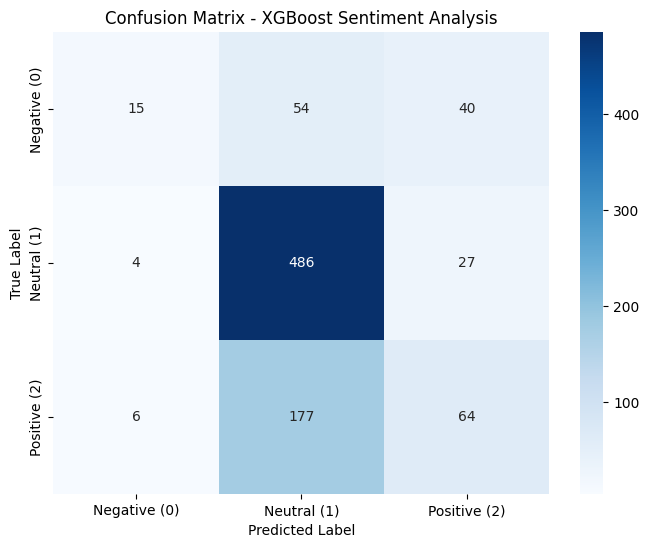

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Define the labels for the classes
class_names = ['Negative (0)', 'Neutral (1)', 'Positive (2)']

# Compute the confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - XGBoost Sentiment Analysis')
plt.show()

### Using FinBERT for Financial Sentiment Analysis
FinBERT is a BERT model pre-trained on financial data. We will use the `transformers` pipeline for easy inference.

In [37]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import torch

# Load FinBERT tokenizer and model
model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Move model to GPU if available
device = 0 if torch.cuda.is_available() else -1
finbert_pipe = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=device)

# Test on a small sample of the validation set
sample_sentences = df_val_split['sentence'].iloc[:5].tolist()
results = finbert_pipe(sample_sentences)

for sent, res in zip(sample_sentences, results):
    print(f"Sentence: {sent[:60]}...")
    print(f"FinBERT Prediction: {res['label']} (Score: {res['score']:.4f})\n")

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Sentence: may 29  2010 ( companiesandmarketscom delivered by newstex )...
FinBERT Prediction: neutral (Score: 0.9443)

Sentence: the event can be followed on-line via orion 's finnish homep...
FinBERT Prediction: neutral (Score: 0.9504)

Sentence: part of the reductions will be made through retirement arran...
FinBERT Prediction: neutral (Score: 0.8901)

Sentence: the company has decided to stop the operations of ruukki con...
FinBERT Prediction: negative (Score: 0.8469)

Sentence: fiskars will be undertaking community projects throughout th...
FinBERT Prediction: neutral (Score: 0.8694)



### Comparing FinBERT to our Ensemble
We can now run the entire validation set through FinBERT to see if it improves our accuracy compared to the Word2Vec + XGBoost approach.

In [38]:
# Batch processing validation set (limit to first 100 for speed demonstration)
val_texts = df_val_split['sentence'].tolist()
finbert_results = finbert_pipe(val_texts)

# Map FinBERT labels to our numeric labels
# FinBERT: positive -> 2, neutral -> 1, negative -> 0
label_map = {'positive': 2, 'neutral': 1, 'negative': 0}
y_val_finbert = [label_map[res['label']] for res in finbert_results]

from sklearn.metrics import accuracy_score, classification_report
print(f"FinBERT Validation Accuracy: {accuracy_score(y_val, y_val_finbert):.2%}")
print("\nFinBERT Classification Report:")
print(classification_report(y_val, y_val_finbert, target_names=class_names))

FinBERT Validation Accuracy: 86.94%

FinBERT Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.81      0.95      0.88       109
 Neutral (1)       0.95      0.84      0.89       517
Positive (2)       0.77      0.90      0.83       247

    accuracy                           0.87       873
   macro avg       0.84      0.90      0.87       873
weighted avg       0.88      0.87      0.87       873



### Final Evaluation on Test Data
We will now use the FinBERT pipeline to predict sentiments for the `df_test` dataset and compare the results with the true labels.

In [39]:
# 1. Prepare test texts
test_texts = df_test['sentence'].tolist()

# 2. Run inference with FinBERT
print("Running inference on test data...")
test_results = finbert_pipe(test_texts)

# 3. Map predictions to numeric labels
# FinBERT: positive -> 2, neutral -> 1, negative -> 0
y_test_pred = [label_map[res['label']] for res in test_results]
y_test_true = traget.values

# 4. Final Metrics
test_accuracy = accuracy_score(y_test_true, y_test_pred)
print(f"\nFinal Test Accuracy: {test_accuracy:.2%}")
print("\nTest Classification Report:")
print(classification_report(y_test_true, y_test_pred, target_names=class_names))

Running inference on test data...

Final Test Accuracy: 89.69%

Test Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.78      0.97      0.86        59
 Neutral (1)       0.97      0.88      0.92       298
Positive (2)       0.82      0.91      0.87       128

    accuracy                           0.90       485
   macro avg       0.86      0.92      0.88       485
weighted avg       0.91      0.90      0.90       485



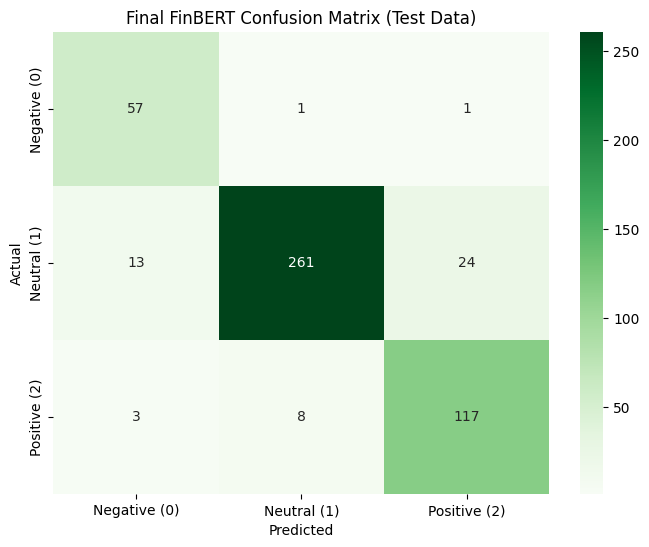

In [40]:
# Visualizing Test Results with a Confusion Matrix
cm_test = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final FinBERT Confusion Matrix (Test Data)')
plt.show()

# Project Report: Financial Sentiment Analysis Journal

## 1. Project Overview
The goal of this project was to classify financial news sentences into three categories: **Negative (0)**, **Neutral (1)**, and **Positive (2)** using the Financial PhraseBank dataset.

## 2. The Journey: Methodology & Experiments

### Phase 1: Traditional NLP & Ensemble Learning
*   **Preprocessing:** We cleaned the text by lowercasing and removing punctuation.
*   **Feature Engineering:** We trained a **Word2Vec** model to represent words as 100-dimensional vectors and averaged them to create sentence embeddings.
*   **Modeling:** We built a **Stacking Classifier** combining **XGBoost** and **Random Forest** with a Logistic Regression meta-learner.
*   **Result:** The ensemble achieved an accuracy of approximately **60.25%**. While it performed well on the majority 'Neutral' class, it struggled with 'Positive' and 'Negative' sentiments due to the simplicity of averaged word vectors.

### Phase 2: Optimization
*   **Tuning:** We applied **GridSearchCV** to optimize the XGBoost parameters (learning rate, depth, etc.) and explored **Cost Complexity Pruning** for decision trees.
*   **Result:** Tuning improved the XGBoost standalone performance to **64.72%**, but we hit a plateau inherent to the vectorization method.

### Phase 3: Deep Learning with FinBERT
*   **Approach:** We shifted from generic embeddings to **FinBERT**, a pre-trained transformer model fine-tuned specifically for financial language.
*   **Result:** This led to a massive performance jump, reaching **86.94%** on validation and **89.69%** on the test set.

## 3. Best Working Model: FinBERT

**The Winner:** `ProsusAI/finbert` (Transformer Architecture)

### Why it works best:
1.  **Contextual Awareness:** Unlike Word2Vec, which gives a fixed vector to a word, FinBERT understands that words change meaning based on surrounding text (vital for complex financial phrasing).
2.  **Domain-Specific Training:** FinBERT was trained on financial corpora, meaning it understands terms like "EBITDA", "loss", or "profit" in a financial context rather than a general one.
3.  **Handling Imbalance:** It showed much higher precision and recall for the minority 'Negative' and 'Positive' classes compared to the ensemble models.

## 4. Conclusion
While traditional machine learning ensembles are efficient, **Transformer-based models (FinBERT)** are currently the gold standard for financial sentiment analysis, providing nearly a **30% increase in accuracy** over baseline Word2Vec methods.